2025-12-28 22-13-21
Outputs will be written to: results/run_2025-12-28 22-13-21
Saved a copy of the config : results/run_2025-12-28 22-13-21/config_copy.yaml
Inputs shape: (19, 2)
Outputs shape: (19,)
First 20 rows of raw data:
    number-1  number-2  log-likelyhood-score  source
9   0.702637  0.926564              0.611205    file
17  0.715000  0.950000              0.597629  week-8
13  0.691873  0.263356              0.596081  week-4
18  0.720000  0.950000              0.565857  week-9
0   0.665800  0.123969              0.538996    file
12  0.722766  0.839711              0.533827  week-3
1   0.877791  0.778628              0.420586    file
3   0.845275  0.711120              0.293993    file
6   0.438166  0.685018              0.244619    file
4   0.454647  0.290455              0.214965    file
11  0.616162  1.000000              0.180119  week-2
10  0.818182  0.939394              0.051646  week-1
16  1.077791  0.617990              0.041708  week-7
7   0.341750  0.028698        

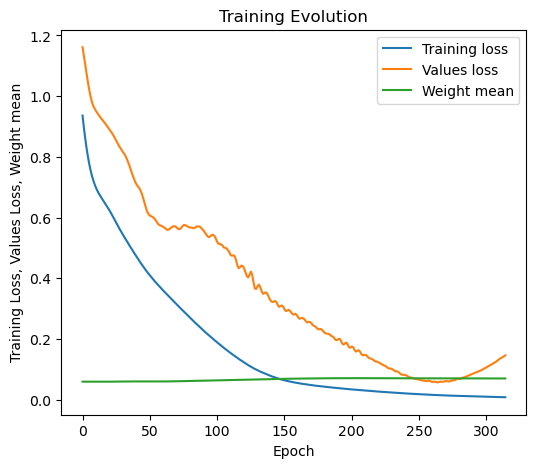

Using 2 dimensions, grid size per axis: 600, downsample: False, stride: 1
Points before downsampling: 360000
Points after downsampling: 360000
Final grid shape: (360000, 2)
sample_strategy=cartesian, Final sample shape: (360000, 2)
⚠️ No filtering applied to candidate grid
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.66993685, 0.32298831]), 'score': 0.031324502476870915, 'dim': 2, 'predicted_y': 0.606754}
{'method': 'PI', 'xi': 0.2, 'kappa': None, 'x': array([0.65856698, 0.3848581 ]), 'score': 0.0014098002855501101, 'dim': 2, 'predicted_y': 0.5683011}
{'method': 'PI', 'xi': 0.5, 'kappa': None, 'x': array([0.69078161, 0.51405676]), 'score': 1.5901914829533094e-06, 'dim': 2, 'predicted_y': 0.44897056}
{'method': 'EI', 'xi': 0.1, 'kappa': None, 'x': array([0.66993685, 0.32298831]), 'score': 0.0007754497471324237, 'dim': 2, 'predicted_y': 0.606754}
{'method': 'EI', 'xi': 0.2, 'kappa': None, 'x': array([0.65477702, 0.3866778 ]), 'score': 5.1

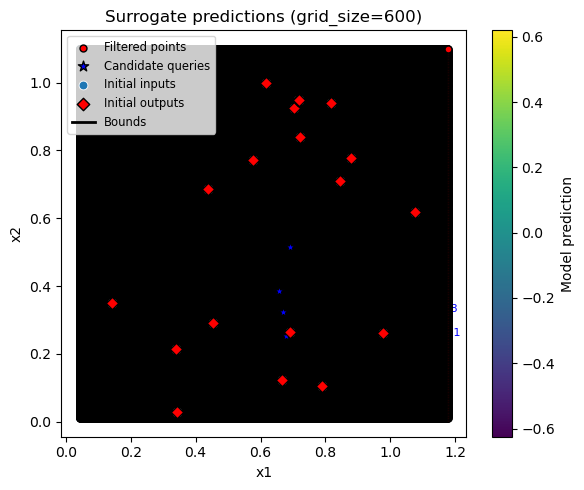

Saved dataframe to: results/run_2025-12-28 22-13-21/df_grid_600_stride1_None_max_raw_lr0.001_ep500.csv
Best candidate: {'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.65856698, 0.3848581 ]), 'score': 1.6507964589259863, 'dim': 2, 'predicted_y': 0.5683011}
    number-1  number-2  log-likelyhood-score  source  log-likelyhood-score-scaled
0   0.658567  0.384858          1.650796e+00  week-x                 1.000000e+01
1   0.669937  0.322988          1.557916e+00  week-x                 9.437361e+00
2   0.677517  0.253840          1.501429e+00  week-x                 9.095182e+00
3   0.702637  0.926564          6.112052e-01    file                 3.702487e+00
4   0.715000  0.950000          5.976294e-01  week-8                 3.620249e+00
5   0.691873  0.263356          5.960814e-01  week-4                 3.610871e+00
6   0.720000  0.950000          5.658573e-01  week-9                 3.427784e+00
7   0.665800  0.123969          5.389961e-01    file                 3.265067e

In [1]:
%matplotlib inline

import sys, os
from pathlib import Path
import matplotlib as mpl

# Ensure parent folder (where run_function.py lives) is on sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Now you can import run_function
from run_function import load_config, instantiate_data_handler, setup_results_logging, run_pipeline, enable_full_df_print, disable_full_df_print, force_text_repr
force_text_repr()  # show all rows/cols

# Load config from the same folder as the notebook
cfg_path = Path.cwd() / "config.yaml"
cfg = load_config(cfg_path)

# set up logging to file
out_dir = setup_results_logging(cfg)

# Apply plotting overrides if present
plot_cfg = cfg.get("plot", {})
mpl.rcParams["figure.figsize"] = tuple(plot_cfg.get("figsize", (12, 8)))

# Instantiate data handler
dh = instantiate_data_handler(cfg["data_module"], cfg["data_class"])
dh.add_weekly_updates()  # ensure weekly points are merged
# 👉 Add inspection here to see the raw loaded data
print("Inputs shape:", dh.inputs.shape)
print("Outputs shape:", dh.outputs.shape)

df_raw = dh.build_dataframe()
print("First 20 rows of raw data:")
print(df_raw.head(20))

# Run pipeline inline (plots will render in notebook)
results = run_pipeline(cfg, dh, out_dir=out_dir)

print("Pipeline finished. Results keys:", list(results.keys()))